Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\Maheshwari M\Desktop\M\Crop-Price-Prediction-Minor-Project\venv\Lib\site-packages\xgboost\data.py:335: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
c:\Users\Maheshwari M\Desktop\M\Crop-Price-Prediction-Minor-Project\venv\Lib\site-packages\xgboost\data.py:338: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  is_categorical_dtype(dtype) or is_pa_ext_categorical_dtype(dtype)
c:\Users\Maheshwari M\Desktop\M\Crop-Price-Prediction-Minor-Project\venv\Lib\site-packages\xgboost\data.py:384: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype):
c:\Users\Maheshwari M\Desktop\M\Crop-Price-Prediction-Minor-Project\venv\Lib\site-packages\xgboost\data.py:359: FutureWarning: is_

XGBoost Performance:
R2: 0.9728
MSE: 35.6878
MAE: 4.2295
RMSE: 5.9739


<Figure size 1000x600 with 0 Axes>

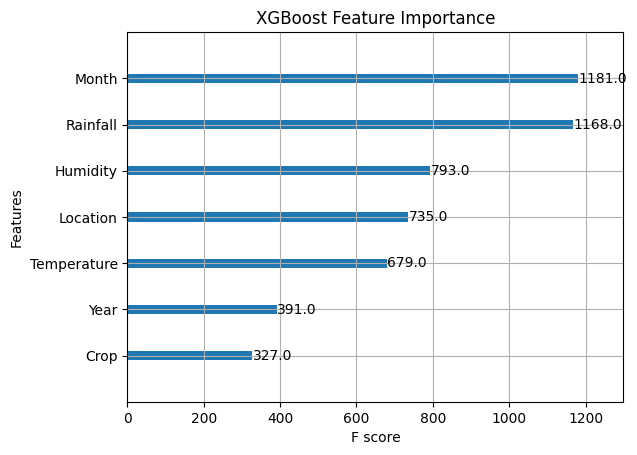


Sample 12-month prediction:
May-2025: ₹60.720001220703125/quintal
Jun-2025: ₹59.11000061035156/quintal
Jul-2025: ₹61.91999816894531/quintal
Aug-2025: ₹63.029998779296875/quintal
Sep-2025: ₹65.94999694824219/quintal
Oct-2025: ₹67.91000366210938/quintal
Nov-2025: ₹64.91999816894531/quintal
Dec-2025: ₹64.55999755859375/quintal
Jan-2026: ₹63.34000015258789/quintal
Feb-2026: ₹61.900001525878906/quintal
Mar-2026: ₹60.06999969482422/quintal
Apr-2026: ₹55.81999969482422/quintal


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('crops_dataset.csv')

# Preprocessing
data['Date'] = pd.to_datetime(data['Date'], format='%b-%y')
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

# Label Encoding
le_location = LabelEncoder()
le_crop = LabelEncoder()
data['Location'] = le_location.fit_transform(data['Location'])
data['Crop'] = le_crop.fit_transform(data['Crop'])

# Features and target
X = data[['Location', 'Crop', 'Rainfall', 'Temperature', 'Humidity', 'Month', 'Year']]
y = data['Crop_Price']

# Stratified train-test split
data['Stratify_Col'] = data['Location'].astype(str) + '_' + data['Crop'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=data['Stratify_Col']
)

# Initialize XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=2
)
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

# Evaluation
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'R2': r2_score(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }

xgb_metrics = evaluate_model(best_xgb, X_test, y_test)
print("XGBoost Performance:")
for metric, value in xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

# Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_xgb)
plt.title('XGBoost Feature Importance')
plt.show()

# Save model
joblib.dump(best_xgb, 'xgb_crop_price_model.joblib')

# Prediction function
def predict_future_prices(model, location, crop, rainfall, temp, humidity, months=12):
    """Predict prices for future months"""
    try:
        loc_encoded = le_location.transform([location])[0]
        crop_encoded = le_crop.transform([crop])[0]
    except ValueError as e:
        raise ValueError(f"Invalid location/crop: {e}")
    
    future_dates = pd.date_range(start=pd.Timestamp.now(), periods=months, freq='M')
    predictions = []
    
    for date in future_dates:
        X_new = np.array([[loc_encoded, crop_encoded, rainfall, temp, humidity, 
                          date.month, date.year]])
        pred = model.predict(X_new)[0]
        predictions.append((date.strftime('%b-%Y'), round(pred, 2)))
    
    return predictions

# Example prediction
example_pred = predict_future_prices(
    best_xgb,
    location="Nellore",
    crop="Maize",
    rainfall=120,
    temp=28,
    humidity=75
)
print("\nSample 12-month prediction:")
for month, price in example_pred:
    print(f"{month}: ₹{price}/quintal")

In [3]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    return r2, mse, mae, rmse

r2_xgb, mse_xgb, mae_xgb, rmse_xgb = evaluate_model(best_xgb, X_test, y_test)
print(f"XGBoost Results: R²: {r2_xgb:.3f}, MSE: {mse_xgb:.3f}, MAE: {mae_xgb:.3f}, RMSE: {rmse_xgb:.3f}")

XGBoost Results: R²: 0.866, MSE: 176.080, MAE: 8.732, RMSE: 13.269


In [4]:
print(f"Model Accuracy (R²): {r2_xgb*100:.2f}%")

Model Accuracy (R²): 86.57%


In [3]:
# At the end of your training script (xg.ipynb)
joblib.dump(le_location, 'le_location.joblib')
joblib.dump(le_crop, 'le_crop.joblib')

['le_crop.joblib']